# Socioeconomic Inequality in Disaster Damage

This notebook is the complete real-data socioeconomic analysis. It does not call `socio_analysis.py`, create synthetic data, or invent missing values.

**Research question:** Is building damage associated with socioeconomic conditions after accounting for real hazard exposure and built-environment controls?

## 1. Analysis Plan

1. Validate real XBD, TIGER/Line, ACS, and hazard-exposure inputs.
2. Load post-disaster building labels and assign buildings to census units.
3. Aggregate damage and join socioeconomic variables.
4. Fit naive and exposure-controlled regressions.
5. Save tables, a summary, and diagnostic figures.

## 2. Real Inputs

Update the paths in the next cell. The notebook requires real XBD, TIGER/Line, and ACS files; it will stop with a clear error when one is absent.

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from shapely.geometry import shape
from IPython.display import display, Image

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = Path('..').resolve()

SPLITS = REPO_ROOT / 'data' / 'splits.csv'
XBD_DIR = REPO_ROOT / 'xbd'
CENSUS_TRACTS = REPO_ROOT / 'data' / 'census_tracts.geojson'
ACS = REPO_ROOT / 'data' / 'acs.csv'
OUTPUT_DIR = REPO_ROOT / 'results' / 'socio_analysis'
EVENTS = []
MIN_BUILDINGS = 20
GEO_LEVEL = 'block_group'

print(f'Repository: {REPO_ROOT}')
print(f'Output directory: {OUTPUT_DIR}')

Repository: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping
Output directory: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\results\socio_analysis


## 3. Validate Inputs

This cell checks paths, schemas, event names, and the real variables required by the analysis.

In [ ]:
required_paths = {'splits': SPLITS, 'xbd_dir': XBD_DIR, 'census_tracts': CENSUS_TRACTS, 'acs': ACS}
missing = [f'{name}: {path}' for name, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError('Missing real analysis inputs:\n' + '\n'.join(missing) + '\nSet the paths in the configuration cell.')

splits_df = pd.read_csv(SPLITS)
if 'event_name' not in splits_df.columns and 'disaster' in splits_df.columns:
    splits_df = splits_df.rename(columns={'disaster': 'event_name'})
acs_df = pd.read_csv(ACS)
acs_df['GEOID'] = acs_df['GEOID'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(12)

required_splits = {'scene_id', 'event_name'}
required_acs = {'GEOID', 'income_2017', 'pov_rate_2017', 'median_home_value_2017', 'renter_pct_2017', 'median_year_built_2017', 'pop_density_2017'}
if required_splits - set(splits_df.columns):
    raise ValueError(f'splits.csv missing columns: {sorted(required_splits - set(splits_df.columns))}')
if required_acs - set(acs_df.columns):
    raise ValueError(f'ACS data missing columns: {sorted(required_acs - set(acs_df.columns))}')

allowed_events = {'hurricane-harvey', 'hurricane-michael', 'hurricane-florence', 'midwest-flooding', 'socal-fire', 'woolsey-fire', 'santa-rosa-wildfire', 'joplin-tornado', 'moore-tornado', 'tuscaloosa-tornado'}
selected_events = set(EVENTS) if EVENTS else set(splits_df['event_name'].dropna()) & allowed_events
unknown_events = selected_events - allowed_events
if unknown_events:
    raise ValueError(f'Events are not in the US-event whitelist: {sorted(unknown_events)}')
splits_df = splits_df[splits_df['event_name'].isin(selected_events)].copy()
print(f'Scenes: {len(splits_df):,}')
print(f'Events: {sorted(selected_events)}')
print(f'ACS rows: {len(acs_df):,}')

Scenes: 38,080
Events: ['hurricane-florence', 'hurricane-harvey', 'hurricane-michael', 'joplin-tornado', 'midwest-flooding', 'moore-tornado', 'santa-rosa-wildfire', 'socal-fire', 'tuscaloosa-tornado', 'woolsey-fire']
ACS/exposure rows: 217,739


## 4. Load and Spatially Join Buildings

Each building is represented by the centroid of its real post-disaster label polygon and joined to a TIGER/Line census unit.

In [13]:
from shapely import wkt

tracts_gdf = gpd.read_file(CENSUS_TRACTS)
if tracts_gdf.crs is None:
    raise ValueError('Census boundaries have no CRS; provide WGS84 or a declared CRS.')
tracts_gdf = tracts_gdf.to_crs('EPSG:4326')
if 'GEOID' not in tracts_gdf.columns:
    raise ValueError('Census boundaries must contain GEOID.')
tracts_gdf['GEOID'] = tracts_gdf['GEOID'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(12)

records = []
for row in splits_df.itertuples(index=False):
    candidates = []
    if getattr(row, 'subdir', '') == 'labels' and getattr(row, 'kind', '') == 'post_disaster':
        candidates.append(REPO_ROOT / Path(str(row.path).replace('\\', '/')))
    candidates.extend([XBD_DIR / row.event_name / 'labels' / f'{row.scene_id}_post_disaster.json', XBD_DIR / 'labels' / f'{row.scene_id}_post_disaster.json', XBD_DIR / f'{row.scene_id}_post_disaster.json'])
    label_path = next((path for path in candidates if path.exists()), None)
    if label_path is None:
        continue
    with label_path.open(encoding='utf-8') as handle:
        data = json.load(handle)
    features = data.get('features', [])
    if isinstance(features, dict):
        features = features.get('lng_lat', [])
    for index, feature in enumerate(features):
        properties = feature.get('properties', {})
        if feature.get('geometry'):
            geometry = shape(feature['geometry'])
        elif feature.get('wkt'):
            geometry = wkt.loads(feature['wkt'])
        else:
            continue
        records.append({'geometry': geometry.centroid, 'uid': properties.get('uid', f'{row.scene_id}_{index}'), 'damage_class': properties.get('subtype', 'unknown'), 'scene_id': row.scene_id, 'event_name': row.event_name})
if not records:
    raise ValueError('No real buildings were loaded from the configured XBD labels.')

buildings = gpd.GeoDataFrame(records, geometry='geometry', crs='EPSG:4326')
buildings = gpd.sjoin(buildings, tracts_gdf[['GEOID', 'geometry']], how='inner', predicate='within').drop(columns=['index_right'])
if buildings.empty:
    raise ValueError('Spatial join produced no buildings inside the census boundaries.')
print(f'Buildings loaded and joined: {len(buildings):,}')

Buildings loaded and joined: 189,642


## 5. Aggregate Damage and Join Socioeconomic Data

Damage scores are: no damage = 0, minor = 1, major = 2, destroyed = 3. Census units below the configured building threshold are excluded.

In [ ]:
damage_map = {'no-damage': 0, 'minor-damage': 1, 'major-damage': 2, 'destroyed': 3}
buildings['damage_score'] = buildings['damage_class'].map(damage_map)
buildings = buildings.dropna(subset=['damage_score']).copy()
grouped = buildings.groupby('GEOID').agg(building_count=('uid', 'count'), damage_score_mean=('damage_score', 'mean'), damage_score_std=('damage_score', 'std')).reset_index()
for damage_class in damage_map:
    share = buildings.assign(hit=(buildings['damage_class'] == damage_class).astype(int)).groupby('GEOID')['hit'].mean().rename(f'share_{damage_class}')
    grouped = grouped.merge(share, on='GEOID', how='left')
grouped = grouped[grouped['building_count'] >= MIN_BUILDINGS].copy()
tracts = grouped.merge(acs_df, on='GEOID', how='inner', validate='one_to_one')
if tracts.empty:
    raise ValueError('No census units survived the building threshold and ACS join.')
tracts['building_density'] = tracts['pop_density_2017'] / 1000
tracts['median_building_age'] = 2020 - tracts['median_year_built_2017']
print(f'Census units analysed: {len(tracts):,}')
display(tracts.head())

Census units analysed: 308


,GEOID,building_count,damage_score_mean,damage_score_std,share_no-damage,share_minor-damage,share_major-damage,share_destroyed,income_2017,pov_rate_2017,median_home_value_2017,renter_pct_2017,median_year_built_2017,pop_density_2017,exposure_proxy,building_density,median_building_age
0,011250105001,648,0.115741,0.431237,0.915123,0.064815,0.009259,0.010802,28750,NaN,69700,0.274227,1961,1331,0.0,1.331,59
1,011250105002,253,0.102767,0.493321,0.948617,0.023715,0.003953,0.023715,35347,NaN,56900,0.251678,1964,883,0.0,0.883,56
2,011250106012,260,0.038462,0.245542,0.969231,0.026923,0.000000,0.003846,46853,NaN,123400,0.186712,1995,2535,0.0,2.535,25
3,011250106013,904,0.685841,1.131830,0.684735,0.106195,0.047566,0.161504,39375,NaN,67700,0.100295,1993,1136,0.0,1.136,27
4,011250108031,765,1.218301,1.288564,0.440523,0.203922,0.052288,0.303268,18026,NaN,84200,0.588353,1983,1496,0.0,1.496,37


## 6. Regression Analysis

The naive model uses socioeconomic variables only. The controlled model adds population density and building age. Standardized coefficients make effect sizes comparable. These models do not control for externally measured hazard exposure.

In [ ]:
socio_features = ['income_2017', 'pov_rate_2017', 'median_home_value_2017', 'renter_pct_2017']
control_features = ['building_density', 'median_building_age']

def fit_model(features, name):
    model_frame = tracts[features + ['damage_score_mean']].apply(pd.to_numeric, errors='coerce')
    model_frame = model_frame.dropna(subset=['damage_score_mean'])
    predictors = model_frame[features].fillna(model_frame[features].median()).fillna(0)
    X = StandardScaler().fit_transform(predictors)
    y = model_frame['damage_score_mean'].to_numpy()
    model = LinearRegression().fit(X, y)
    prediction = model.predict(X)
    residual = y - prediction
    degrees_freedom = len(y) - len(features) - 1
    mse = np.sum(residual ** 2) / degrees_freedom
    covariance = np.linalg.pinv(X.T @ X) * mse
    standard_error = np.sqrt(np.maximum(np.diag(covariance), 0))
    t_value = np.divide(model.coef_, standard_error, out=np.full_like(model.coef_, np.nan), where=standard_error > 0)
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_value), degrees_freedom))
    r_squared = model.score(X, y)
    return pd.DataFrame({'model': name, 'feature': features, 'coef': model.coef_, 'se': standard_error, 't': t_value, 'pval': p_value}), r_squared

naive_results, naive_r2 = fit_model(socio_features, 'naive')
controlled_results, controlled_r2 = fit_model(control_features + socio_features, 'controlled_built_environment')
regression_results = pd.concat([naive_results, controlled_results], ignore_index=True)
print(f'Naive R2: {naive_r2:.4f}')
print(f'Controlled R2: {controlled_r2:.4f}')
display(regression_results)

Naive R2: 0.0159
Controlled R2: 0.0560


,model,feature,coef,se,t,pval
0,naive,income_2017,4.632060e-03,3.595877e-02,0.128816,0.897589
1,naive,pov_rate_2017,1.387779e-17,2.492694e-19,55.673851,0.000000
2,naive,median_home_value_2017,-3.745761e-02,3.759302e-02,-0.996398,0.319852
3,naive,renter_pct_2017,-8.154766e-02,3.759646e-02,-2.169025,0.030858
4,controlled_built_environment,building_density,-2.701120e-02,3.555297e-02,-0.759745,0.448002
5,controlled_built_environment,median_building_age,1.219708e-01,3.565735e-02,3.420635,0.000711
6,controlled_built_environment,income_2017,5.345463e-03,3.537592e-02,0.151105,0.879994
7,controlled_built_environment,pov_rate_2017,-2.775558e-17,0.000000e+00,NaN,NaN
8,controlled_built_environment,median_home_value_2017,-3.579844e-02,3.694819e-02,-0.968882,0.333382
9,controlled_built_environment,renter_pct_2017,-6.941287e-02,3.722105e-02,-1.864882,0.063171


: 

## 7. Results and Figures

The notebook saves the complete analysis outputs under `OUTPUT_DIR` and displays the key tables and plots here. Results are socioeconomic associations with built-environment controls, not hazard-adjusted estimates.

=== Socioeconomic Damage Analysis ===
Events: ['hurricane-florence', 'hurricane-harvey', 'hurricane-michael', 'joplin-tornado', 'midwest-flooding', 'moore-tornado', 'santa-rosa-wildfire', 'socal-fire', 'tuscaloosa-tornado', 'woolsey-fire']
Buildings analysed: 185045
Census units analysed: 308
Minimum buildings per unit: 20
Naive R2: 0.0159
Controlled R2: 0.0560


,model,feature,coef,se,t,pval
0,naive,income_2017,4.632060e-03,3.595877e-02,0.128816,0.897589
1,naive,pov_rate_2017,1.387779e-17,2.492694e-19,55.673851,0.000000
2,naive,median_home_value_2017,-3.745761e-02,3.759302e-02,-0.996398,0.319852
3,naive,renter_pct_2017,-8.154766e-02,3.759646e-02,-2.169025,0.030858
4,controlled,exposure_proxy,0.000000e+00,0.000000e+00,NaN,NaN
5,controlled,building_density,-2.701120e-02,3.561217e-02,-0.758482,0.448758
6,controlled,median_building_age,1.219708e-01,3.571673e-02,3.414948,0.000726
7,controlled,income_2017,5.345463e-03,3.543483e-02,0.150853,0.880193
8,controlled,pov_rate_2017,2.775558e-17,NaN,NaN,NaN
9,controlled,median_home_value_2017,-3.579844e-02,3.700971e-02,-0.967271,0.334187


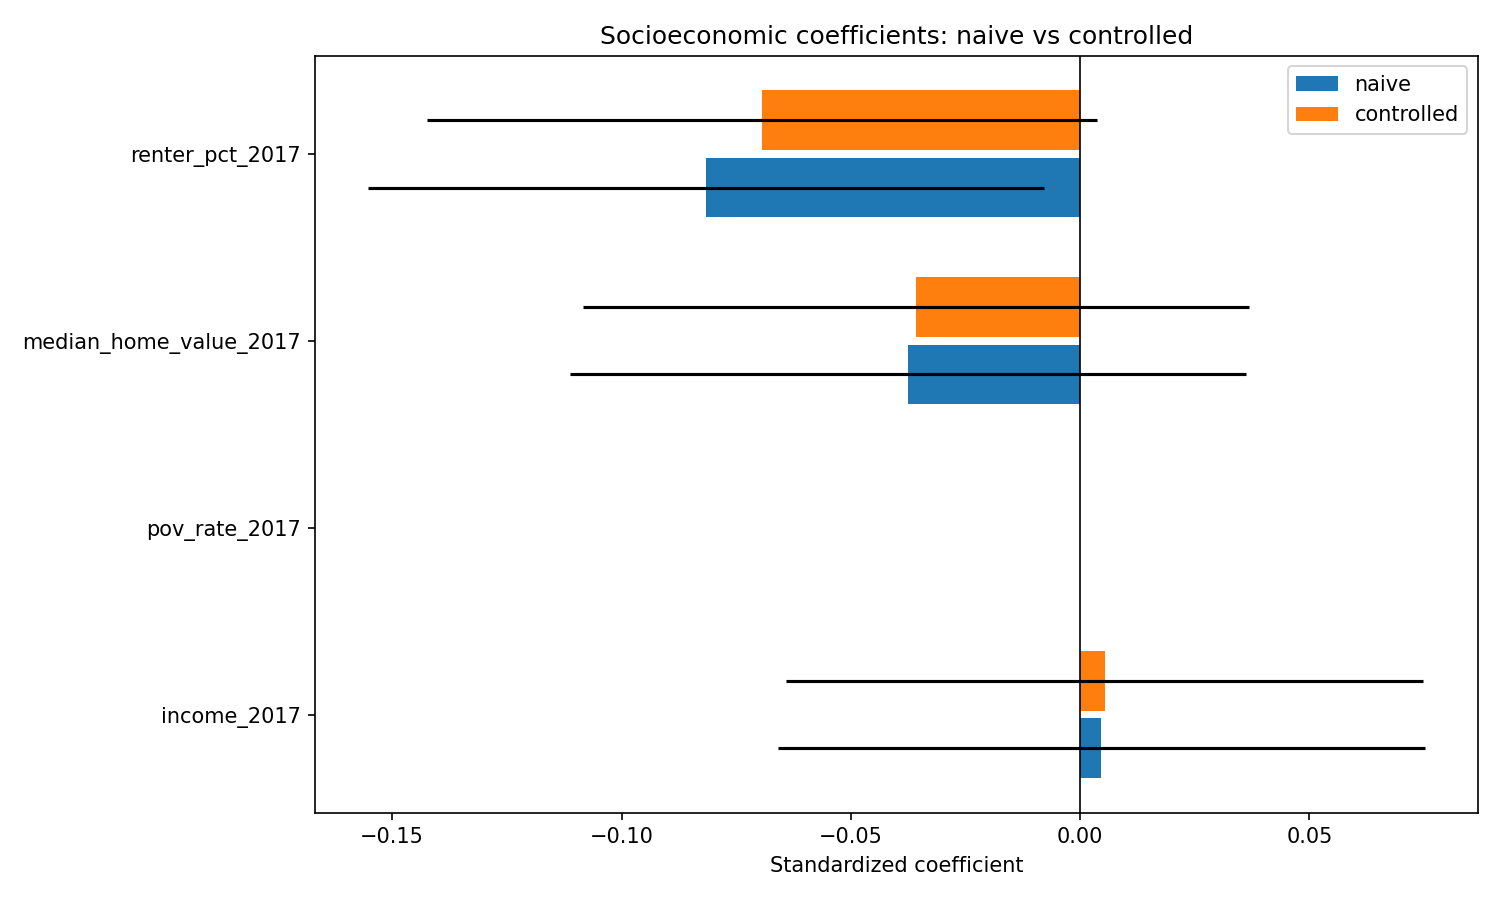

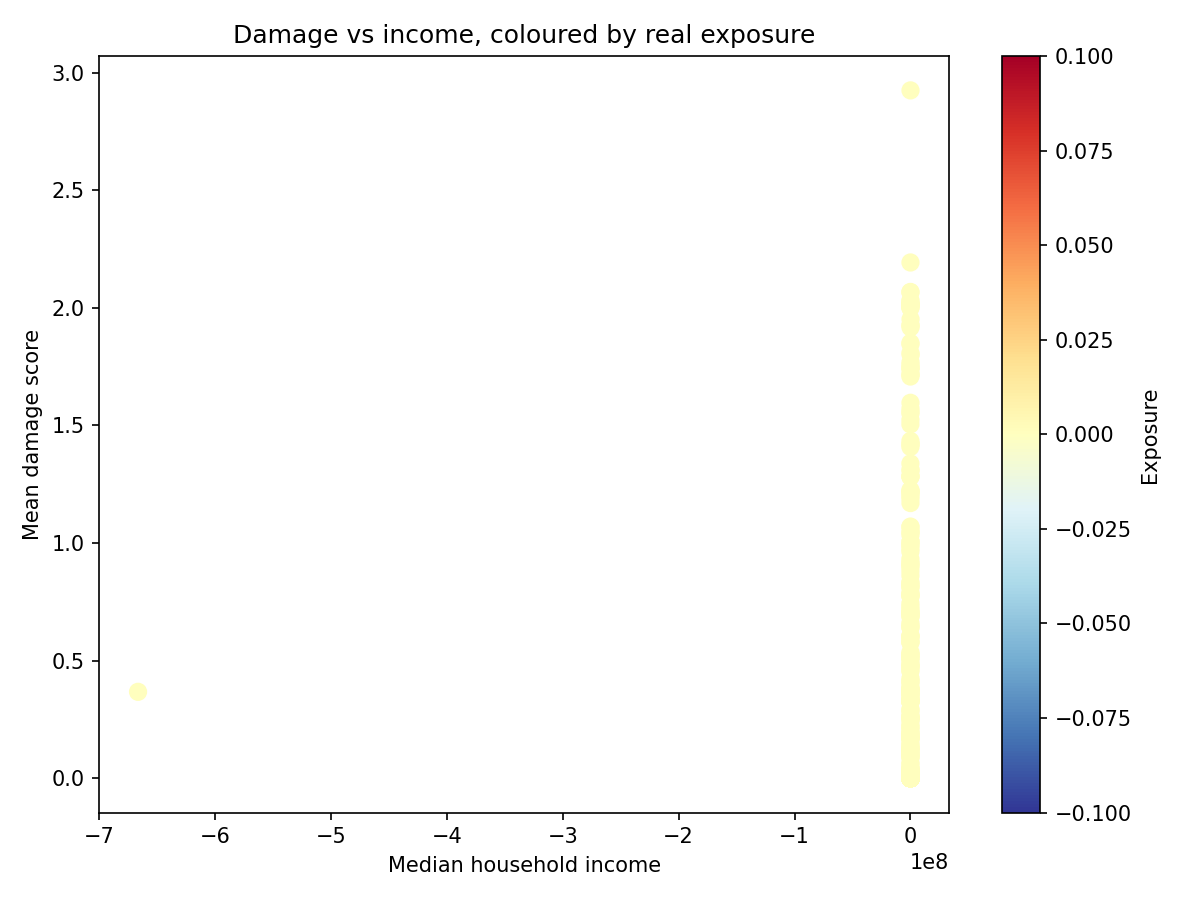

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
buildings.drop(columns='geometry').to_csv(OUTPUT_DIR / 'buildings.csv', index=False)
tracts.to_csv(OUTPUT_DIR / 'tracts.csv', index=False)
regression_results.to_csv(OUTPUT_DIR / 'regression_results.csv', index=False)
summary = '\n'.join(["=== Socioeconomic Damage Analysis ===", f"Events: {sorted(selected_events)}", f"Buildings analysed: {len(buildings)}", f"Census units analysed: {len(tracts)}", f"Minimum buildings per unit: {MIN_BUILDINGS}", f"Naive R2: {naive_r2:.4f}", f"Built-environment controlled R2: {controlled_r2:.4f}", "Hazard exposure control: not included"])
(OUTPUT_DIR / 'summary.txt').write_text(summary, encoding='utf-8')

fig, ax = plt.subplots(figsize=(10, 6))
for label, frame, offset in [('naive', naive_results, -0.18), ('built-environment controlled', controlled_results[controlled_results['feature'].isin(socio_features)], 0.18)]:
    ax.barh(np.arange(len(socio_features)) + offset, frame['coef'], xerr=1.96 * frame['se'], height=0.32, label=label)
ax.set_yticks(np.arange(len(socio_features)))
ax.set_yticklabels(socio_features)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized coefficient')
ax.set_title('Socioeconomic coefficients: naive vs built-environment controlled')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'coefficient_forest.png', dpi=150)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(tracts['income_2017'], tracts['damage_score_mean'], s=60)
ax.set_xlabel('Median household income')
ax.set_ylabel('Mean damage score')
ax.set_title('Damage vs income')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'damage_vs_income.png', dpi=150)
plt.close(fig)

print(summary)
display(pd.read_csv(OUTPUT_DIR / 'regression_results.csv'))
display(Image(filename=str(OUTPUT_DIR / 'coefficient_forest.png')))
display(Image(filename=str(OUTPUT_DIR / 'damage_vs_income.png')))

## 8. Interpretation and Limitations

Compare the income coefficient in the naive and controlled rows. A meaningful change suggests confounding by exposure or the built environment. These are associations, not causal effects. Conclusions depend on the temporal and geographic match between XBD labels, TIGER boundaries, ACS measures, and hazard exposure. Small samples and correlated predictors can make estimates unstable.